In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import sys
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / "Scripts").is_dir()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")

scripts_directory = PROJECT_ROOT / "Scripts" / "Helpers"

if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))

from Helpers import *

In [3]:
def load_rank_data(filename):
    data_path = PROJECT_ROOT / "Data/Processed Data/Affordability" / filename
    df = pd.read_csv(data_path)[["Population", "A_Affordability_Ratio"]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Population", "A_Affordability_Ratio"])
    df = df[(df["Population"] > 0) & (df["A_Affordability_Ratio"] > 0)].reset_index(drop=True)
    return df

lawyers = load_rank_data("Supplementary_Figure_7_Lawyers_data.csv")
pharmacists = load_rank_data("Supplementary_Figure_7_Pharmacists_data.csv")

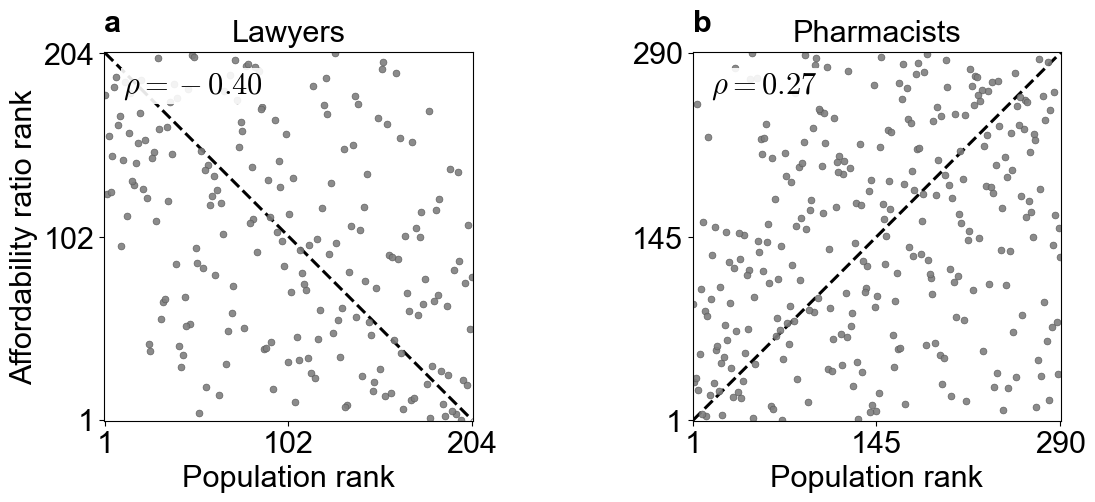

In [4]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "cm",
    "font.size": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22
})

def plot_rank_panel(ax, df, title, panel_label, show_ylabel=True):
    population = df["Population"].to_numpy()
    affordability = df["A_Affordability_Ratio"].to_numpy()

    # Rank 1 = largest value
    population_rank = df["Population"].rank(method="average", ascending=False).to_numpy()
    affordability_rank = df["A_Affordability_Ratio"].rank(method="average", ascending=False).to_numpy()

    rho, _ = spearmanr(population, affordability)
    n = len(df)
    color = "#7f7f7f"

    ax.scatter(population_rank, affordability_rank, s=24, alpha=0.9, color=color,
               edgecolor=darker(color), linewidths=0.5, zorder=2)

    # Perfect rank agreement or reversal
    if rho >= 0:
        ax.plot([1, n], [1, n], "--", color="k", lw=2.2, zorder=1)
    else:
        ax.plot([1, n], [n, 1], "--", color="k", lw=2.2, zorder=1)

    ax.text(0.05, 0.95, rf"$\rho = {rho:.2f}$", transform=ax.transAxes,
            ha="left", va="top", fontsize=22,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=1.5),
            zorder=3)

    ax.text(0.00, 1.04, panel_label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=22, fontweight="bold", clip_on=False)

    ax.set_title(title, fontsize=22, pad=8)
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(0.5, n + 0.5)

    mid_rank = int(round(n / 2))
    ax.set_xticks([1, mid_rank, n])
    ax.set_yticks([1, mid_rank, n])

    ax.set_xlabel("Population rank", fontsize=22)
    ax.set_ylabel("Affordability ratio rank" if show_ylabel else "", fontsize=22)
    ax.tick_params(axis="both", labelsize=22)
    ax.set_aspect("equal", adjustable="box")


fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

plot_rank_panel(axes[0], lawyers, "Lawyers", "a", show_ylabel=True)
plot_rank_panel(axes[1], pharmacists, "Pharmacists", "b", show_ylabel=False)

plt.tight_layout(w_pad=2.5)

save_dir = PROJECT_ROOT / "Figures/Supplementary Figure 7"
save_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(save_dir / "Supplementary_Figure_7.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)